In [3]:
from ipywidgets import FileUpload
from IPython.display import display

uploader = FileUpload(
    accept=".py",
    multiple=False
)

display(uploader)

FileUpload(value=(), accept='.py', description='Upload')

In [4]:
from pathlib import Path
import shutil
import os

source = Path(
    "/kaggle/input/datasets/kenechifortune/"
    "context-sr-project/context_sr_student_package/"
    "context_sr_student_package"
)

project = Path("/kaggle/working/context_project")

if not project.exists():
    shutil.copytree(source, project)

os.chdir(project)

print(Path.cwd())

/kaggle/working/context_project


In [10]:
!python -u code/context_sr_explore_torch.py \
  --Lx 2 \
  --Ly 3 \
  --t-steps 50 \
  --t-max 10 \
  --d-model 8 \
  --num-heads 2 \
  --num-layers 1 \
  --ctx-tokens 8 \
  --train-protocols 1 \
  --test-protocols 1 \
  --steps 500 \
  --dtype float32 \
  --sr-reg 0.01 \
  --integrator heun \
  --test-family ood \
  --print-every 10 \
  --out runs/tangent_run

Output directory: /kaggle/working/context_project/runs/tangent_run
Plot directory:    /kaggle/working/context_project/runs/tangent_run/plots
N=6, DIM=64, context P=64, dtype=float32
/kaggle/working/context_project/code/context_sr_explore_torch.py:262: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print(f'fit {step:5d} loss={lf:.4e} meanF={float(fids.mean()):.6f} worstF={float(fids.min()):.6f} smooth={float(smooth):.3e}')
fit     0 loss=5.9454e-01 meanF=0.405461 worstF=0.010408 smooth=1.002e-04
fit    10 loss=5.0912e-01 meanF=0.490879 worstF=0.165915 smooth=1.891e-04
fit    20 loss=4.7611e-01 meanF=0.523889 worstF=0.304691 smooth=4.679e-04
fit    30 loss=4.5849e-01 meanF=0.541509 worstF=0.355065 smooth=7.987e-04
fit    40 loss=4.5395e-01 meanF=0.546050 worstF=0.378145 smooth=1.099e-03
fit    50 l

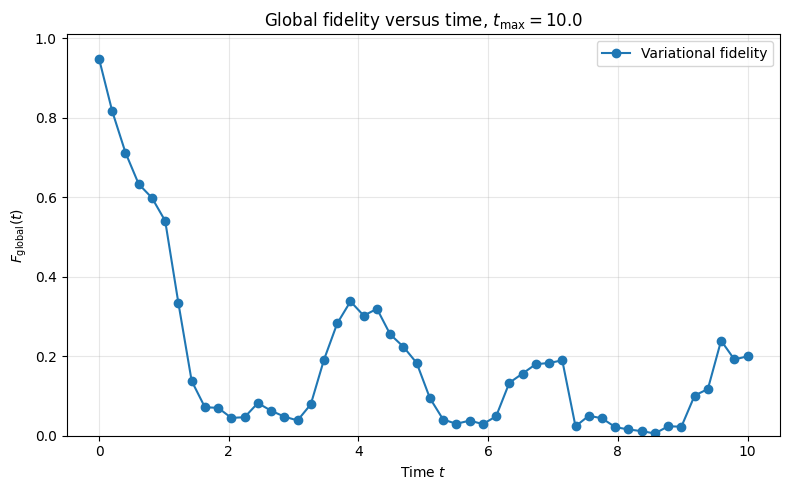

In [6]:
import json
import numpy as np
import matplotlib.pyplot as plt

run_dir = "/kaggle/working/context_project/runs/tangent_run"

with open(f"{run_dir}/summary.json") as f:
    summary = json.load(f)

tmax = summary["config"]["t_max"]

data = np.load(f"{run_dir}/results.npz")
fidelity = data["gfid_0"]

times = np.linspace(0, tmax, len(fidelity))

plt.figure(figsize=(8, 5))
plt.plot(times, fidelity, "o-", label="Variational fidelity")

plt.xlabel("Time $t$")
plt.ylabel(r"$F_{\mathrm{global}}(t)$")
plt.title(f"Global fidelity versus time, $t_{{\\max}}={tmax}$")
plt.ylim(0, 1.01)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

run_dir = Path(
    "/kaggle/working/context_project/runs/tangent_run"
)

data = np.load(run_dir / "results.npz")

O = data["log_derivatives_0"]       # (time, configuration, parameter)
Dexact = data["exact_log_derivatives_0"]
Mdot = data["Mdot_0"]               # (time, context tokens, d-model)

# Flatten Mdot's context dimensions
Mdot_flat = Mdot.reshape(Mdot.shape[0], -1)

# Construct the variational logarithmic derivative:
# D_var(sigma,t) = sum_a O(sigma,a,t) * Mdot(a,t)
Dvar = np.einsum("tsp,tp->ts", O, Mdot_flat)

times = np.linspace(0, 1, Dvar.shape[0])

# Difference between the two tangent directions
residual = Dexact - Dvar

exact_rms = np.sqrt(np.mean(np.abs(Dexact)**2, axis=1))
var_rms = np.sqrt(np.mean(np.abs(Dvar)**2, axis=1))
residual_rms = np.sqrt(np.mean(np.abs(residual)**2, axis=1))

# Directional alignment
overlap = np.sum(np.conj(Dexact) * Dvar, axis=1)

alignment = np.real(overlap) / (
    np.sqrt(np.sum(np.abs(Dexact)**2, axis=1))
    * np.sqrt(np.sum(np.abs(Dvar)**2, axis=1))
    + 1e-12
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(times, exact_rms, label="Exact tangent")
axes[0, 0].plot(times, var_rms, label="Variational tangent")
axes[0, 0].set_title("Tangent magnitudes")
axes[0, 0].set_xlabel("Time $t$")
axes[0, 0].set_ylabel("RMS magnitude")
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(times, residual_rms, color="red")
axes[0, 1].set_title("Tangent residual")
axes[0, 1].set_xlabel("Time $t$")
axes[0, 1].set_ylabel(r"$\|D_{\rm exact}-D_{\rm var}\|$")
axes[0, 1].grid(True)

axes[1, 0].plot(times, alignment, color="purple")
axes[1, 0].set_title("Tangent directional alignment")
axes[1, 0].set_xlabel("Time $t$")
axes[1, 0].set_ylabel("Alignment")
axes[1, 0].set_ylim(-1, 1)
axes[1, 0].grid(True)

# Show one basis configuration's complex motion
config = 0

axes[1, 1].plot(
    times,
    Dexact[:, config].real,
    label="Exact real"
)
axes[1, 1].plot(
    times,
    Dvar[:, config].real,
    "--",
    label="Variational real"
)
axes[1, 1].set_title(f"Tangent for basis configuration {config}")
axes[1, 1].set_xlabel("Time $t$")
axes[1, 1].set_ylabel(r"$\partial_t\log\psi$")
axes[1, 1].legend()
axes[1, 1].grid(True)

fig.tight_layout()

plot_path = run_dir / "tangent_motion_comparison.png"
fig.savefig(plot_path, dpi=200)
plt.show()

print("Saved:", plot_path)

KeyError: 'log_derivatives_0 is not a file in the archive'

In [13]:
python test_learnMdot_sr_math.py

SyntaxError: invalid syntax (4249278041.py, line 1)

In [9]:
%%bash
cd /kaggle/working/context_project
export CUDA_VISIBLE_DEVICES=0
export XLA_PYTHON_CLIENT_PREALLOCATE=false

python -u code/learnMdot_best_original.py \
  --Lx 2 \
  --Ly 3 \
  --t-steps 10 \
  --t-max 0.2 \
  --batch-size 1 \
  --num-time-points 2 \
  --num-mc-samples 32 \
  --d-model 16 \
  --fno-width 32 \
  --num-layers 1 \
  --ctx-tokens 2 \
  --steps 100 \
  --anchor-pretrain-steps 10 \
  --benchmark-every 10 \
  --print-every 1 \
  --checkpoint-path runs/best_original_gpu_test.pkl

JAX is using: [CudaDevice(id=0)]
--- Training Pure FNO Global Model (TFIM + longitudinal field, OBC) ---
M0 mode: random_unit_rows
Phase mode: softsign
Gauge centering: global
Score function weight: 1.0
Attention kernel: matmul
Self-KV cache: False
Context dynamics: direct FNO Mdot with simpson integration
Site order: snake
Pre-training Anchor Condition...
TDVP Training...

--- Running Benchmark (Exact vs NOQS) ---
Saved benchmark plot to: /kaggle/working/context_project/benchmark_plots/benchmark_step_00009.png
[benchmark step 9] avg_fid=0.610826, final_fid=0.586378, best_fid=0.641419, mx_mae=8.596660e-02, zz_mae=1.060005e-01

--- Running Benchmark (Exact vs NOQS) ---
Saved benchmark plot to: /kaggle/working/context_project/benchmark_plots/benchmark_step_00019.png
[benchmark step 19] avg_fid=0.643508, final_fid=0.614869, best_fid=0.670087, mx_mae=7.888004e-02, zz_mae=1.385021e-01

--- Running Benchmark (Exact vs NOQS) ---
Saved benchmark plot to: /kaggle/working/context_project/benchma

Loss: 3.00624: 100%|██████████| 100/100 [00:51<00:00,  1.94it/s]


In [6]:
!pip install -q equinox optax

/usr/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 3.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 1.9 MB/s eta 0:00:00


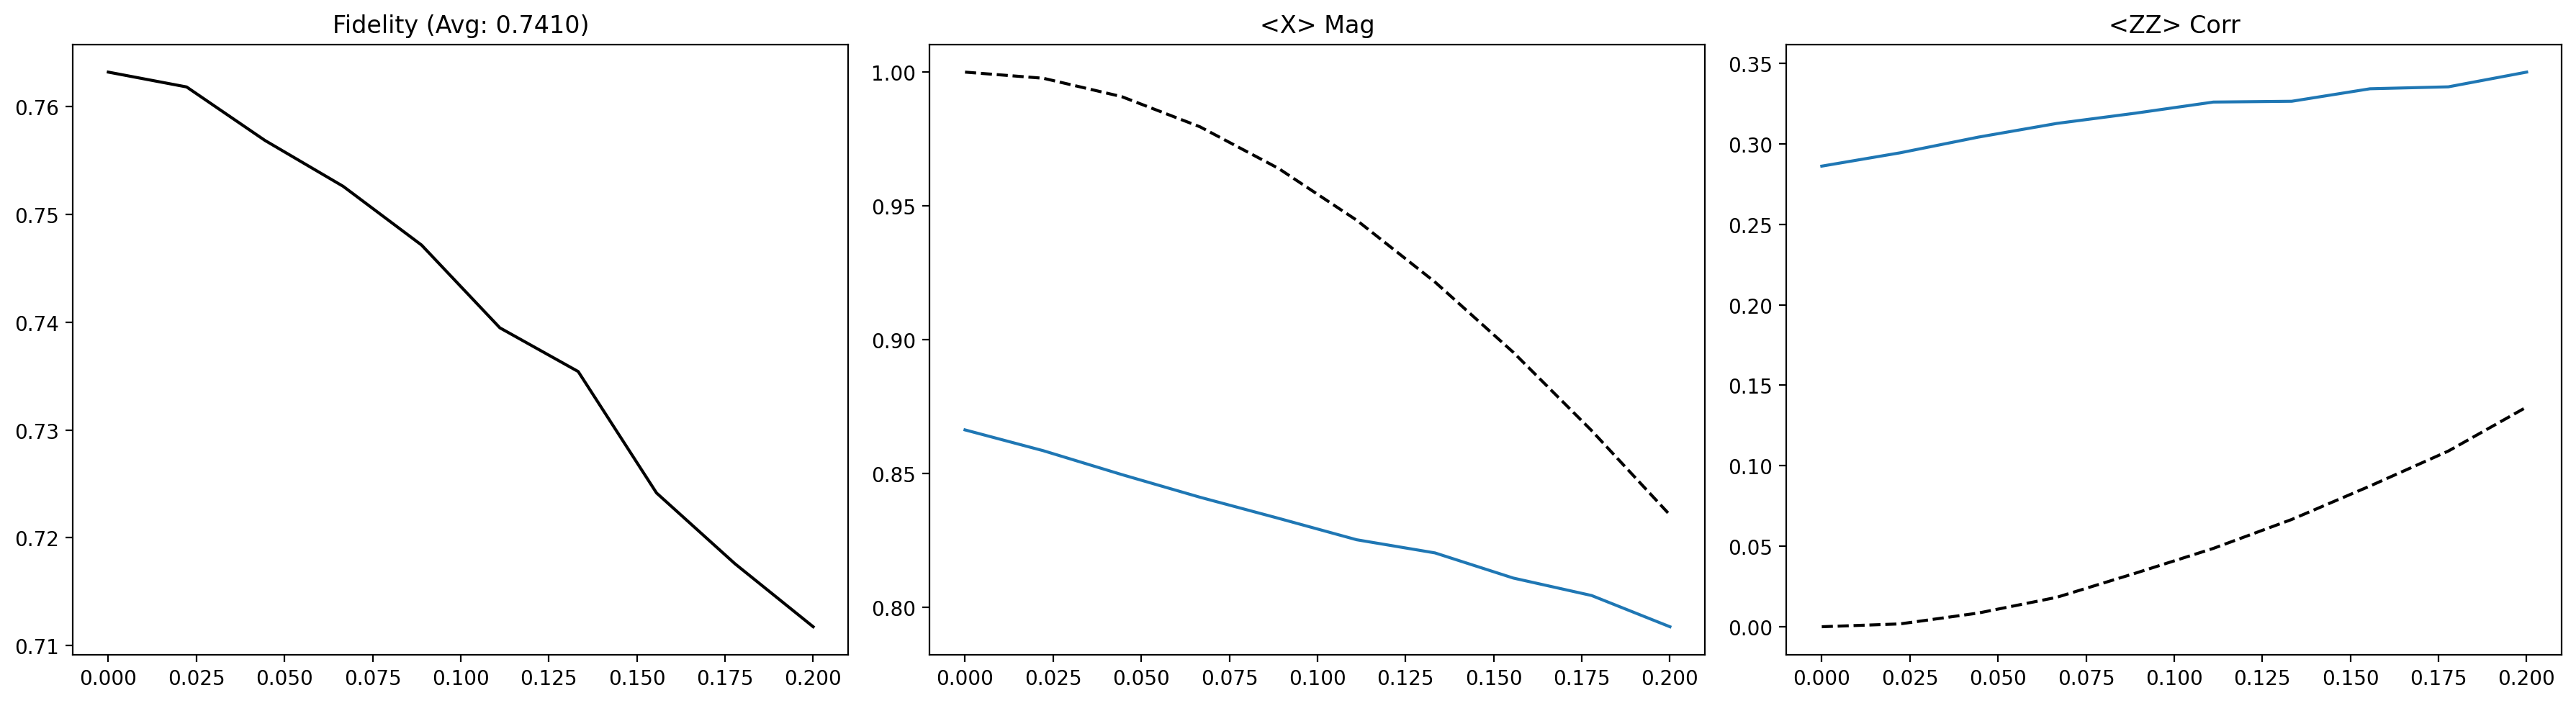

In [10]:
from IPython.display import Image, display

display(Image(
    filename="/kaggle/working/context_project/benchmark_plots/benchmark_step_00099.png"
))

In [1]:
import jax
print(jax.devices())
print(jax.default_backend())

[CudaDevice(id=0), CudaDevice(id=1)]
gpu
